# Introduction to MNIST Classification
MNIST classification is a basic image classification problem where a model learns to recognize handwritten digits from 0 to 9. Each image in the dataset is a grayscale image of size 28 x 28 pixels.

In this notebook, we will build a Simple Deep Neural Network (SimpleDNN) to classify MNIST digits. The focus is not just on training a model, but also on understanding the dataset, the model architecture, the training process, and the evaluation results.

# Objective
Understand what the MNIST dataset contains.
Prepare image data for a neural network.
Build and train a fully connected DNN for digit classification.
Monitor training loss, validation loss, and test loss.
Evaluate the model using accuracy, a classification report, and a confusion matrix.
<br>
<br>


# What is MNIST?
MNIST is a well-known benchmark dataset used for handwritten digit recognition.

-It contains grayscale images of digits from 0 to 9.

-Each image has size 28 x 28 pixels.

-The dataset has 60,000 training images and 10,000 test images.

-The goal is to predict which digit appears in each image.

MNIST is commonly used for introducing image classification because it is small, clean, and easy to visualize.

# Import Required Libraries


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import copy
import torch
import random
import torchvision
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import confusion_matrix, classification_report

# Setting Random Seed for Consistent Results

In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Data Preprocessing and Transformation

In [ ]:
#We normalize MNIST images so the model trains faster and more stably.
#The mean and standard deviation used here are standard values for MNIST.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Loading The Dataset


In [ ]:
# Load the MNIST training dataset.
# train=True means we are loading the 60,000 images used for learning.
train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# Load the MNIST test dataset.
# train=False means we are loading the 10,000 images used only for final evaluation.
test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

print(f"Total training images available: {len(train_dataset)}")
print(f"Total test images available: {len(test_dataset)}")


100%|██████████| 9.91M/9.91M [00:00<00:00, 14.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 357kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.25MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.34MB/s]

Total training images available: 60000
Total test images available: 10000


# Defining Data Loaders

In [ ]:
# We split the original training dataset into:
# 1. train_subset -> used to update the model weights
# 2. val_subset   -> used to monitor validation loss during training
# The test set remains completely separate for final evaluation.

train_size = int(0.9 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_subset, val_subset = random_split(
    train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Training samples: {len(train_subset)}")
print(f"Validation samples: {len(val_subset)}")
print(f"Test samples: {len(test_dataset)}")


Training samples: 54000
Validation samples: 6000
Test samples: 10000


# Visualize Sample Handwritten Digits

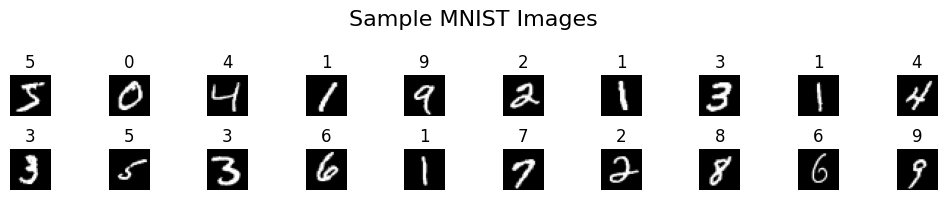

In [ ]:
def show_samples(dataset, n=20):
    plt.figure(figsize=(10, 2))

    for i in range(n):
        image, label = dataset[i]
        plt.subplot(2, n//2, i+1)
        plt.imshow(image.squeeze(), cmap='gray')
        plt.title(label)
        plt.axis('off')

    plt.suptitle('Sample MNIST Images', fontsize=16)
    plt.tight_layout()
    plt.show()

show_samples(train_dataset)

# Check Class Balance in the Dataset

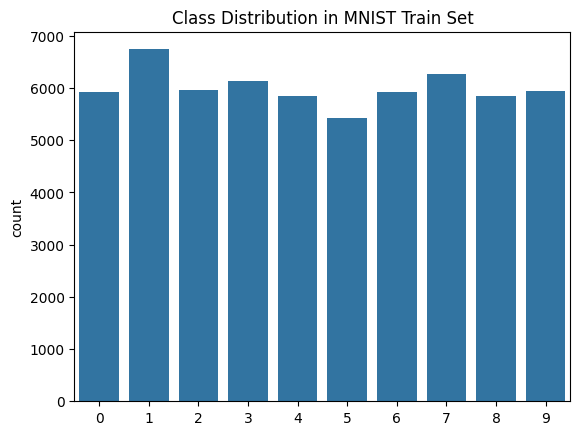

In [ ]:
labels = [label for _, label in train_dataset]
sns.countplot(x=labels)
plt.title('Class Distribution in MNIST Train Set')
plt.show()

# Build a Fully Connected Deep Neural Network
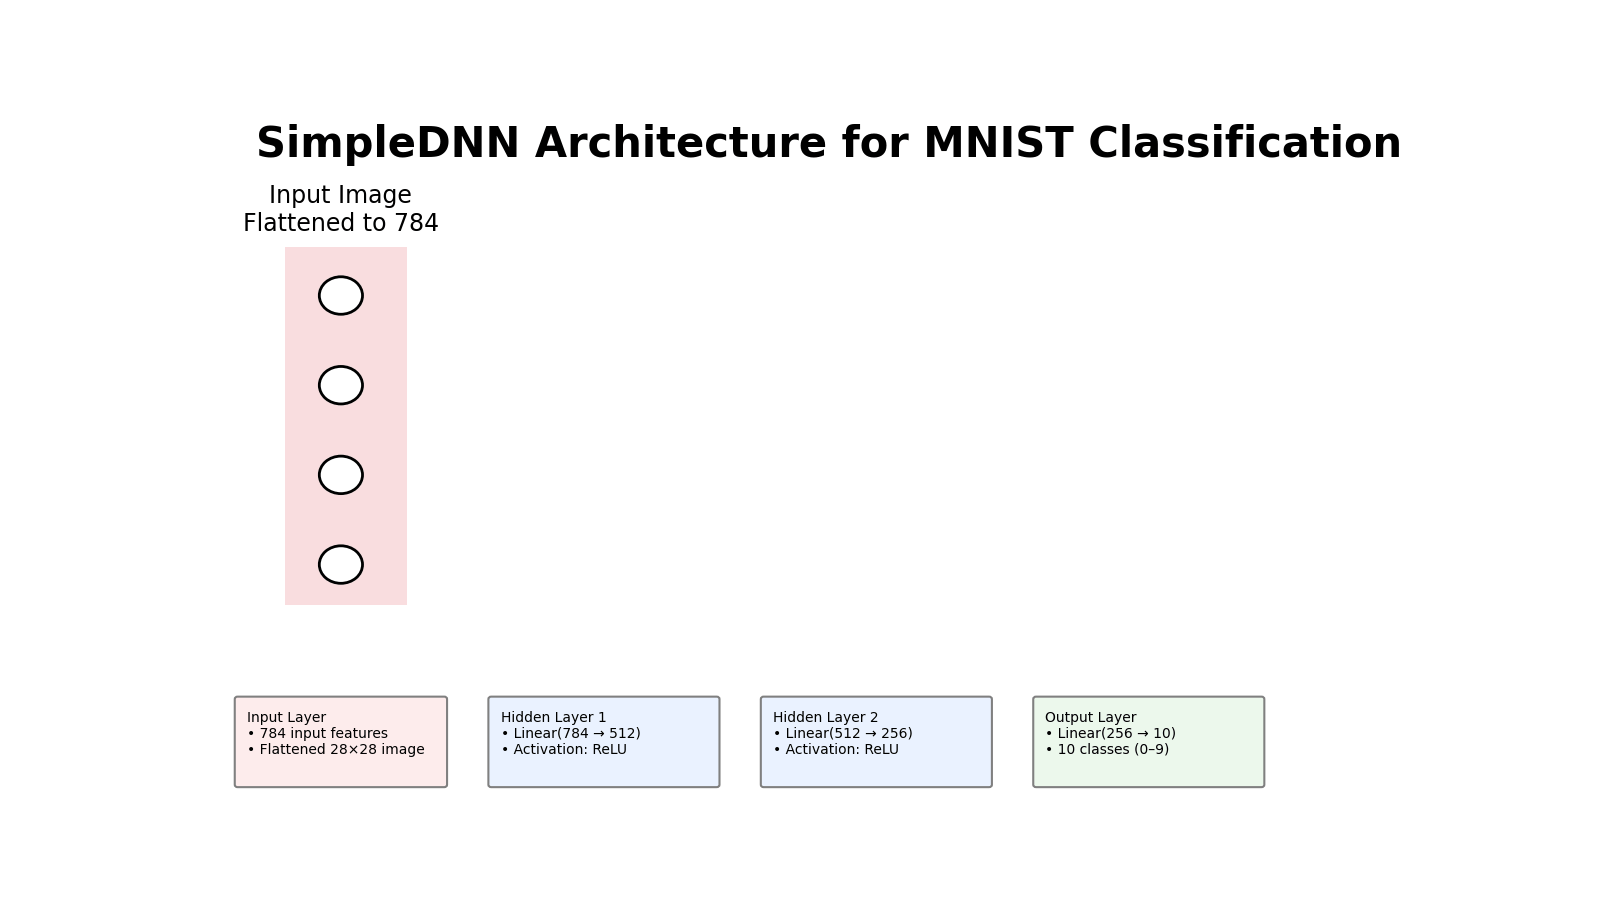
This model is called a fully connected neural network because each neuron in one layer is connected to every neuron in the next layer.


# Model idea
**-Input image size:** 28 x 28 = 784 features


**-Hidden Layer 1:** 512 neurons + ReLU


**-Hidden Layer 2:** 256 neurons + ReLU


**-Output Layer:** 10 neurons for the 10 digit classes


The architecture diagram below helps students connect the code with the flow of data through the network.





In [ ]:
class SimpleDNN(nn.Module):
    def __init__(self, device):
        super(SimpleDNN, self).__init__()
        self.device = device

        self.flatten = nn.Flatten()
        self.layers = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 10)
        )

        self.to(self.device)

    def forward(self, x):
        x = self.flatten(x)
        return self.layers(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleDNN(device)

# Define Loss Function, Optimizer, and Training Criterion

# Loss function
We use CrossEntropyLoss because this is a multi-class classification problem.

# Optimizer
We use Adam to update model weights efficiently.

# Training criterion
Instead of training for a fixed epochs without checking performance, we will:

-set a maximum number of epochs,

-monitor the validation loss,

-stop training early if validation loss does not improve for several epochs.

This makes the training process more meaningful for students because the number of epochs is decided by model performance, not by an arbitrary fixed value.

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Train the DNN Using Validation Loss as a Criterion


In [ ]:
train_losses = []
val_losses = []
test_losses = []

train_accuracies = []
val_accuracies = []
test_accuracies = []

max_epochs = 20
patience = 3
min_delta = 0.001

best_val_loss = float('inf')
epochs_without_improvement = 0
best_model_state = copy.deepcopy(model.state_dict())
best_epoch = 0

for epoch in range(max_epochs):

    # Training
    model.train()
    running_train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

        # Training accuracy inside loop
        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    avg_train_loss = running_train_loss / len(train_loader)
    train_accuracy = 100 * train_correct / train_total

    train_losses.append(avg_train_loss)
    train_accuracies.append(train_accuracy)

    # Validation and test
    model.eval()
    running_val_loss = 0.0
    running_test_loss = 0.0

    val_correct = 0
    val_total = 0
    test_correct = 0
    test_total = 0

    with torch.no_grad():

        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

            # Validation accuracy inside loop
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_test_loss += loss.item()

            # Test accuracy inside loop
            _, predicted = torch.max(outputs, 1)
            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()

    avg_val_loss = running_val_loss / len(val_loader)
    avg_test_loss = running_test_loss / len(test_loader)

    val_accuracy = 100 * val_correct / val_total
    test_accuracy = 100 * test_correct / test_total

    val_losses.append(avg_val_loss)
    test_losses.append(avg_test_loss)

    val_accuracies.append(val_accuracy)
    test_accuracies.append(test_accuracy)

    print(
        f"Epoch [{epoch + 1}/{max_epochs}] | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f} | "
        f"Test Loss: {avg_test_loss:.4f} | "
        f"Train Acc: {train_accuracy:.2f}% | "
        f"Val Acc: {val_accuracy:.2f}% | "
        f"Test Acc: {test_accuracy:.2f}%"
    )

    # Early stopping
    if avg_val_loss < best_val_loss - min_delta:
        best_val_loss = avg_val_loss
        epochs_without_improvement = 0
        best_model_state = copy.deepcopy(model.state_dict())
        best_epoch = epoch + 1
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        print(f"Early stopping triggered after {epoch + 1} epochs.")
        break

model.load_state_dict(best_model_state)

print(f"Best validation loss achieved: {best_val_loss:.4f}")
print(f"Best model found at epoch: {best_epoch}")

Epoch [1/20] | Train Loss: 0.2680 | Val Loss: 0.1335 | Test Loss: 0.1219 | Train Acc: 91.89% | Val Acc: 95.90% | Test Acc: 96.19%
Epoch [2/20] | Train Loss: 0.1303 | Val Loss: 0.1235 | Test Loss: 0.1091 | Train Acc: 96.06% | Val Acc: 96.30% | Test Acc: 96.39%
Epoch [3/20] | Train Loss: 0.1053 | Val Loss: 0.0919 | Test Loss: 0.0915 | Train Acc: 96.84% | Val Acc: 97.17% | Test Acc: 97.05%
Epoch [4/20] | Train Loss: 0.0887 | Val Loss: 0.0805 | Test Loss: 0.0701 | Train Acc: 97.31% | Val Acc: 97.70% | Test Acc: 97.93%
Epoch [5/20] | Train Loss: 0.0811 | Val Loss: 0.0813 | Test Loss: 0.0718 | Train Acc: 97.45% | Val Acc: 97.62% | Test Acc: 97.91%
Epoch [6/20] | Train Loss: 0.0720 | Val Loss: 0.0879 | Test Loss: 0.0833 | Train Acc: 97.80% | Val Acc: 97.50% | Test Acc: 97.62%
Epoch [7/20] | Train Loss: 0.0674 | Val Loss: 0.0755 | Test Loss: 0.0685 | Train Acc: 97.94% | Val Acc: 98.02% | Test Acc: 98.01%
Epoch [8/20] | Train Loss: 0.0639 | Val Loss: 0.0878 | Test Loss: 0.0825 | Train Acc: 98.0

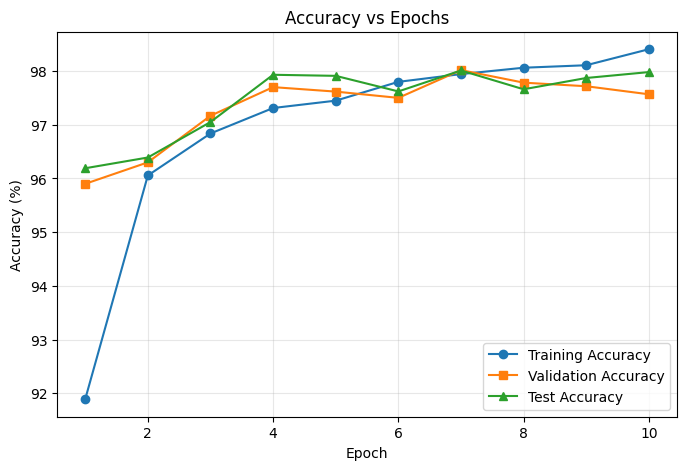

In [ ]:
epochs = range(1, len(train_accuracies) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_accuracies, marker='o', label='Training Accuracy')
plt.plot(epochs, val_accuracies, marker='s', label='Validation Accuracy')
plt.plot(epochs, test_accuracies, marker='^', label='Test Accuracy')

plt.title("Accuracy vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Save & Load The Model

In [ ]:
os.makedirs('/content/drive/MyDrive/DNN_models', exist_ok=True)
MODEL_DIR = '/content/drive/MyDrive/DNN_models'
BEST_MODEL_PATH = os.path.join(MODEL_DIR, 'best_model.pth')
torch.save(best_model_state, BEST_MODEL_PATH)
torch.save(model.state_dict(), os.path.join(MODEL_DIR, 'final_model.pth'))
torch.save(model.state_dict(), os.path.join(MODEL_DIR, 'final_model.pth'))
model.load_state_dict(torch.load(BEST_MODEL_PATH))
model.eval()

SimpleDNN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (layers): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=256, out_features=10, bias=True)
  )
)

# Plot Training Loss & Test Loss


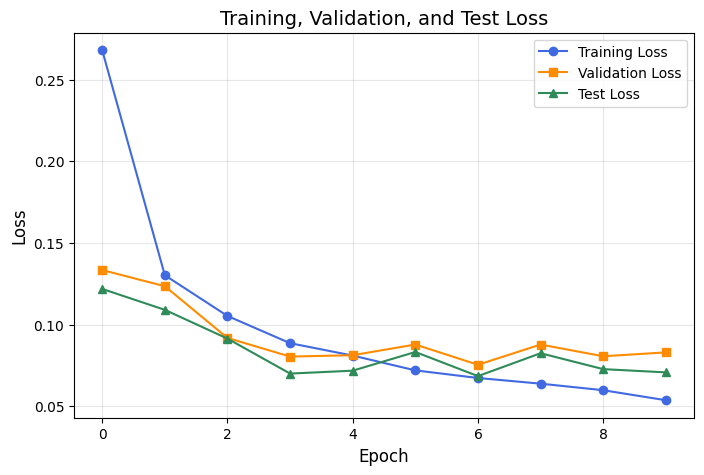

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, marker='o', label='Training Loss', color='royalblue')
plt.plot(val_losses, marker='s', label='Validation Loss', color='darkorange')
plt.plot(test_losses, marker='^', label='Test Loss', color='seagreen')
plt.title("Training, Validation, and Test Loss", fontsize=14)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Evaluate the Model on Test Data

**Classification Report**


In [ ]:
model.eval()
all_pred = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_pred.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("\nClassification Report:")
print(classification_report(all_labels, all_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.99      1.00      0.99      1135
           2       0.99      0.98      0.98      1032
           3       0.99      0.98      0.99      1010
           4       0.98      0.98      0.98       982
           5       0.98      0.98      0.98       892
           6       0.98      0.99      0.98       958
           7       0.98      0.98      0.98      1028
           8       0.97      0.97      0.97       974
           9       0.97      0.97      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



# Model Accuracy

In [ ]:
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {100 * correct / total:.2f}%")

Test Accuracy: 98.01%


# Analyze Predictions Using a Confusion Matrix
# Idea behind the confusion matrix
A confusion matrix helps students see which digits are predicted correctly and which digits are confused with other digits.

Rows represent the true labels.
Columns represent the predicted labels.
A strong model gives high values along the main diagonal.
Off-diagonal values show the mistakes made by the model.
For example, if the model often predicts 5 as 3, that confusion will appear in the matrix.

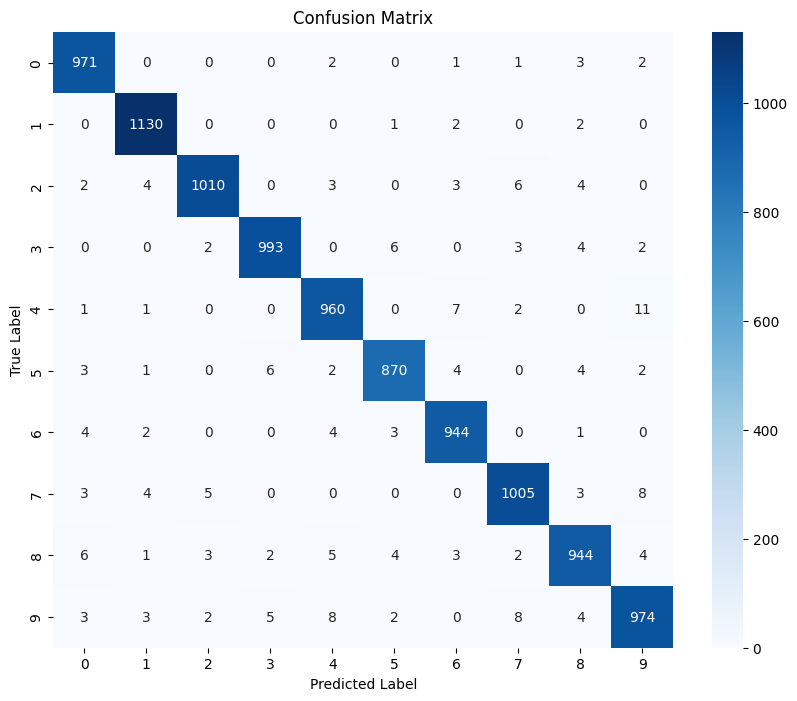

In [ ]:
# A confusion matrix compares true labels with predicted labels.
# Each row shows the actual class, and each column shows the predicted class.
# Higher values on the diagonal mean the model is classifying that digit correctly more often.
# Off-diagonal values highlight which digits the model tends to confuse.
cm = confusion_matrix(all_labels, all_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


# Predict a Single Handwritten Digit

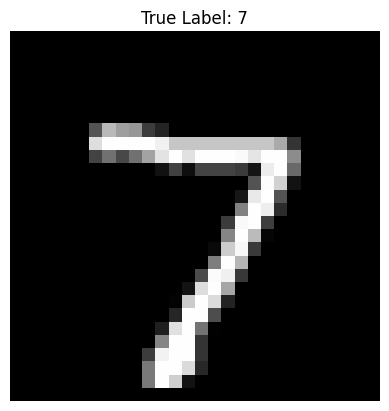

Predicted Class: 7


In [ ]:
sample_img, sample_label = test_dataset [0]
plt.imshow(sample_img.squeeze(), cmap="gray")
plt.title(f"True Label: {sample_label}")
plt.axis('off')
plt.show()
sample_tensor = sample_img.unsqueeze(0).to(device)
with torch.no_grad():
  output = model(sample_tensor)
  predicted_class = torch.argmax(output).item()
  print(f"Predicted Class: {predicted_class}")

# Misclassified Count per Class

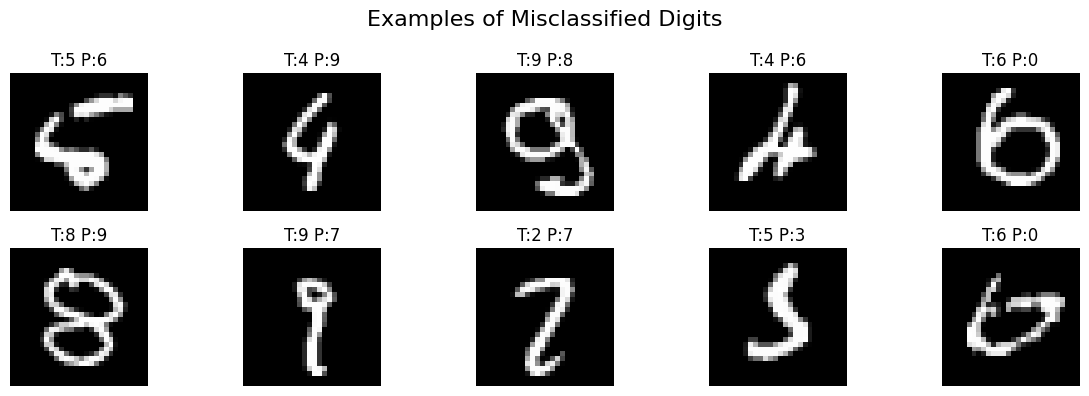

In [ ]:
# Load best weights into model
model.load_state_dict(best_model_state)
model.eval()

misclassified = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)   # ✅ FIXED
        _, predicted = torch.max(outputs, 1)

        for img, true, pred in zip(images, labels, predicted):
            if true != pred:
                misclassified.append((img.cpu(), true.cpu().item(), pred.cpu().item()))
            if len(misclassified) >= 10:
                break
        if len(misclassified) >= 10:
            break

plt.figure(figsize=(12, 4))
for i, (img, true, pred) in enumerate(misclassified):
    plt.subplot(2, 5, i + 1)
    plt.imshow(img.squeeze(), cmap='gray')
    plt.title(f"T:{true} P:{pred}")
    plt.axis('off')

plt.suptitle("Examples of Misclassified Digits", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
misclassified_count = np.zeros(10)

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        for i in range(len(labels)):
            if predicted[i] != labels[i]:
                misclassified_count[labels[i]] += 1

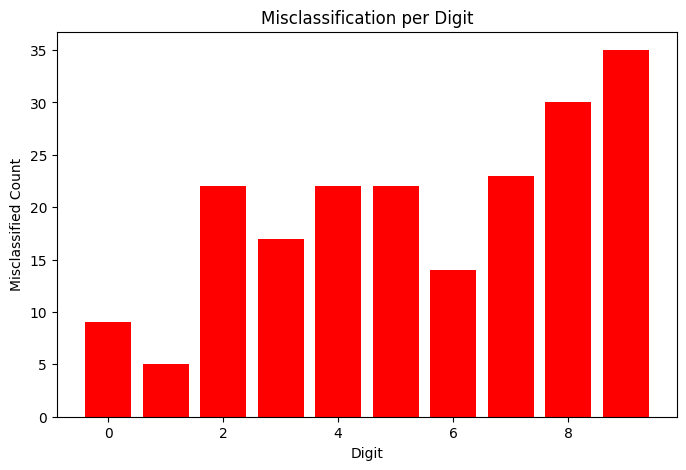

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(range(10), misclassified_count, color='red')
plt.xlabel("Digit")
plt.ylabel("Misclassified Count")
plt.title("Misclassification per Digit")
plt.show()

# Conclusion

In this notebook, we built a SimpleDNN for **MNIST digit classification** and studied the full workflow:

understanding the dataset,

preparing image tensors,

building a fully connected neural network,

training with a validation-based stopping criterion,

monitoring training, validation, and test loss,

and evaluating predictions with accuracy, a classification report, and a confusion matrix.

This makes the notebook more suitable for teaching because students can connect the model architecture, the training process, and the evaluation results in one complete example.